In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


In [2]:
df= pd.read_csv(r"C:\Users\ADITYA GUPTA\Downloads\Data\synthetic_drug_data.csv")

In [3]:
df.shape

(1000000, 10)

In [4]:
df.isnull().sum()

ReportID                 0
PatientAge               0
Gender                   0
DrugName                 0
Dosage                   0
DurationDays             0
ConcomitantDrugs    437828
ADR_Code                 0
Seriousness              0
OnsetDays                0
dtype: int64

In [5]:
df.describe()

,PatientAge,DurationDays,ADR_Code,OnsetDays
count,1000000.000000,1000000.000000,1.000000e+06,1000000.000000
mean,49.603926,29.997227,1.002093e+07,7.350763
std,14.729829,5.476767,1.392893e+04,3.111634
min,18.000000,7.000000,1.000008e+07,0.000000
25%,39.000000,26.000000,1.001274e+07,5.000000
50%,50.000000,30.000000,1.001626e+07,7.000000
75%,60.000000,34.000000,1.003766e+07,9.000000
max,90.000000,58.000000,1.004770e+07,31.000000


In [6]:
df.head(3)

,ReportID,PatientAge,Gender,DrugName,Dosage,DurationDays,ConcomitantDrugs,ADR_Code,Seriousness,OnsetDays
0,REP-VJpHH7RG,52,Other,Ibuprofen,658mg,31,"Simvastatin, Fluoxetine, Gabapentin",10016256,mild,12
1,REP-xZHEIV6F,64,Male,Atorvastatin,359mg,33,NaN,10019211,mild,5
2,REP-j2PXcrTb,45,Female,Amoxicillin,179mg,28,NaN,10016256,mild,3


In [7]:
df['NumConcomitant'] = df['ConcomitantDrugs'].str.count(',').add(1).fillna(0).astype(int)

In [8]:
df.head(3)

,ReportID,PatientAge,Gender,DrugName,Dosage,DurationDays,ConcomitantDrugs,ADR_Code,Seriousness,OnsetDays,NumConcomitant
0,REP-VJpHH7RG,52,Other,Ibuprofen,658mg,31,"Simvastatin, Fluoxetine, Gabapentin",10016256,mild,12,3
1,REP-xZHEIV6F,64,Male,Atorvastatin,359mg,33,NaN,10019211,mild,5,0
2,REP-j2PXcrTb,45,Female,Amoxicillin,179mg,28,NaN,10016256,mild,3,0


In [9]:
df.isnull().mean() * 100  # finding percentage of missing data

ReportID             0.0000
PatientAge           0.0000
Gender               0.0000
DrugName             0.0000
Dosage               0.0000
DurationDays         0.0000
ConcomitantDrugs    43.7828
ADR_Code             0.0000
Seriousness          0.0000
OnsetDays            0.0000
NumConcomitant       0.0000
dtype: float64

In [10]:
df.head(2)

,ReportID,PatientAge,Gender,DrugName,Dosage,DurationDays,ConcomitantDrugs,ADR_Code,Seriousness,OnsetDays,NumConcomitant
0,REP-VJpHH7RG,52,Other,Ibuprofen,658mg,31,"Simvastatin, Fluoxetine, Gabapentin",10016256,mild,12,3
1,REP-xZHEIV6F,64,Male,Atorvastatin,359mg,33,NaN,10019211,mild,5,0


In [11]:
df['ConcomitantDrugs'] = df['ConcomitantDrugs'].fillna('')
df.head(5)

,ReportID,PatientAge,Gender,DrugName,Dosage,DurationDays,ConcomitantDrugs,ADR_Code,Seriousness,OnsetDays,NumConcomitant
0,REP-VJpHH7RG,52,Other,Ibuprofen,658mg,31,"Simvastatin, Fluoxetine, Gabapentin",10016256,mild,12,3
1,REP-xZHEIV6F,64,Male,Atorvastatin,359mg,33,,10019211,mild,5,0
2,REP-j2PXcrTb,45,Female,Amoxicillin,179mg,28,,10016256,mild,3,0
3,REP-vzYm2NEH,72,Female,Prednisone,46mg,29,"Metformin, Lisinopril",10013968,mild,6,2
4,REP-WWcINmT6,56,Male,Atorvastatin,936mg,28,,10037660,mild,9,0


In [12]:
# Get counts
concomitant_counts = df['ConcomitantDrugs'].fillna(0).str.split(', ').explode().value_counts()

# Print drug name and count without column name
for drug, count in concomitant_counts.items():
    print(f"{drug}: {count}")

: 437828
Ibuprofen: 56438
Atorvastatin: 56421
Albuterol: 56369
Amoxicillin: 56354
Prednisone: 56328
Levothyroxine: 56300
Omeprazole: 56233
Sertraline: 56226
Hydrochlorothiazide: 56193
Losartan: 56183
Amlodipine: 56169
Aspirin: 56132
Citalopram: 56116
Paracetamol: 56096
Metformin: 56047
Simvastatin: 56012
Lisinopril: 56002
Fluoxetine: 55959
Gabapentin: 55856
Warfarin: 55851


In [13]:
df['Seriousness'].value_counts()

Seriousness
mild        800261
moderate    149718
severe       39946
fatal        10075
Name: count, dtype: int64

In [14]:
# Filter severe cases and show age and drug name
severe_cases = df[df['Seriousness'] == 'severe'][['DrugName', 'PatientAge']]
severe_cases

,DrugName,PatientAge
5,Atorvastatin,68
17,Aspirin,56
22,Lisinopril,48
34,Warfarin,39
54,Gabapentin,20
...,...,...
999928,Lisinopril,60
999934,Aspirin,53
999949,Prednisone,61
999951,Aspirin,56


In [15]:
# Group by Seriousness and calculate mean OnsetDays
avg_onset = df.groupby('Seriousness')['OnsetDays'].mean()
print(avg_onset)

Seriousness
fatal       14.028883
mild         7.000730
moderate     7.000381
severe      13.992089
Name: OnsetDays, dtype: float64


In [16]:
df.head(2)

,ReportID,PatientAge,Gender,DrugName,Dosage,DurationDays,ConcomitantDrugs,ADR_Code,Seriousness,OnsetDays,NumConcomitant
0,REP-VJpHH7RG,52,Other,Ibuprofen,658mg,31,"Simvastatin, Fluoxetine, Gabapentin",10016256,mild,12,3
1,REP-xZHEIV6F,64,Male,Atorvastatin,359mg,33,,10019211,mild,5,0


In [17]:
gender_count = df['Gender'].value_counts()

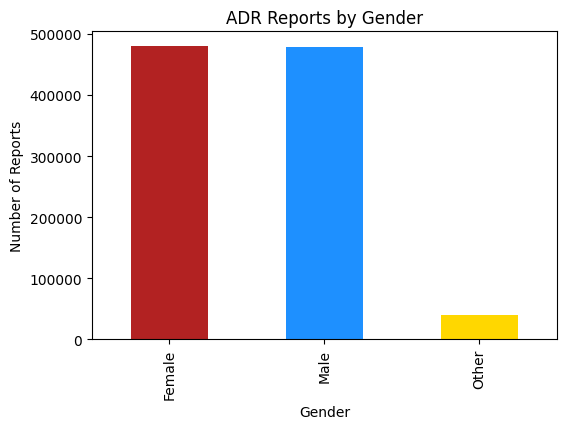

In [18]:
# Gender Wise ADR
plt.figure(figsize=(6, 4))

gender_count.plot(kind='bar', color=['#B22222', '#1E90FF', '#FFD700'])
plt.title('ADR Reports by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Reports')
plt.show()


In [19]:
# Create age groups
bins = [0, 30, 50, 70, 200]  # Age boundaries
labels = ['0-30', '31-50', '51-70', '71+']
df['AgeGroup'] = pd.cut(df['PatientAge'], bins=bins, labels=labels, right=True)

In [20]:
df.head(3)

,ReportID,PatientAge,Gender,DrugName,Dosage,DurationDays,ConcomitantDrugs,ADR_Code,Seriousness,OnsetDays,NumConcomitant,AgeGroup
0,REP-VJpHH7RG,52,Other,Ibuprofen,658mg,31,"Simvastatin, Fluoxetine, Gabapentin",10016256,mild,12,3,51-70
1,REP-xZHEIV6F,64,Male,Atorvastatin,359mg,33,,10019211,mild,5,0,51-70
2,REP-j2PXcrTb,45,Female,Amoxicillin,179mg,28,,10016256,mild,3,0,31-50


In [21]:
severe_by_age = df[df['Seriousness'] == 'severe'].groupby('AgeGroup').size()
most_severe_age = severe_by_age.idxmax() if not severe_by_age.empty else "No severe reactions"
print(f"Age group with most severe reactions: {most_severe_age}")
print(severe_by_age)

Age group with most severe reactions: 31-50
AgeGroup
0-30      4056
31-50    16990
51-70    15651
71+       3249
dtype: int64


In [22]:
concomitant_counts = df['ConcomitantDrugs'].str.split(',').explode().value_counts()
most_common = concomitant_counts.nlargest(5)
count = concomitant_counts.max()

print(f"{most_common} : {count}")

ConcomitantDrugs
                 437828
Levothyroxine     28428
Sertraline        28309
 Amoxicillin      28305
 Albuterol        28281
Name: count, dtype: int64 : 437828


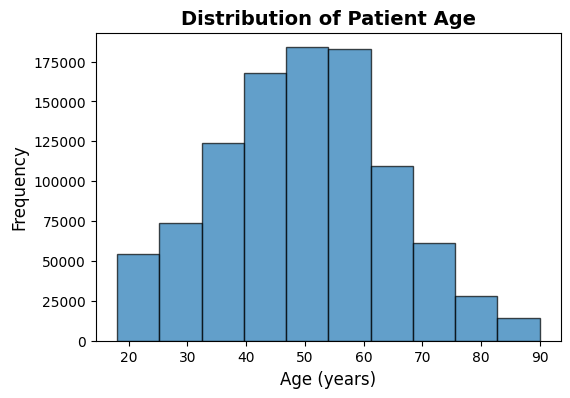

In [23]:
plt.figure(figsize=(6, 4))
plt.hist(df['PatientAge'].fillna('Unknown'), bins=10, edgecolor='black', alpha=0.7)
plt.title('Distribution of Patient Age', fontsize=14, fontweight='bold')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.show()

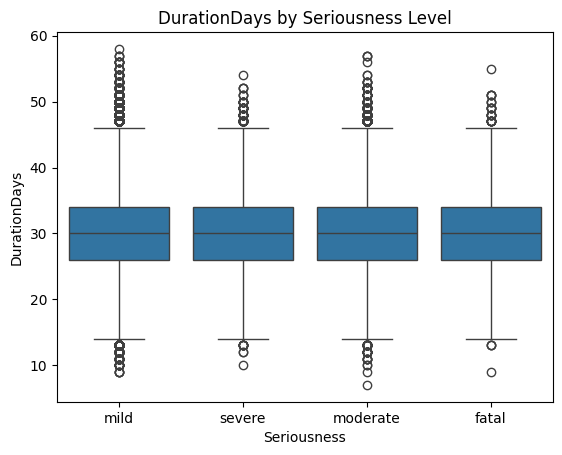

In [24]:
sns.boxplot(x='Seriousness', y='DurationDays', data=df)
plt.title('DurationDays by Seriousness Level')
plt.show()

In [25]:
df.head(2)

,ReportID,PatientAge,Gender,DrugName,Dosage,DurationDays,ConcomitantDrugs,ADR_Code,Seriousness,OnsetDays,NumConcomitant,AgeGroup
0,REP-VJpHH7RG,52,Other,Ibuprofen,658mg,31,"Simvastatin, Fluoxetine, Gabapentin",10016256,mild,12,3,51-70
1,REP-xZHEIV6F,64,Male,Atorvastatin,359mg,33,,10019211,mild,5,0,51-70


In [26]:
df['Dosage'] = df['Dosage'].str.replace('mg', '', regex=False).astype(int)

In [27]:
df['Dosage'] = df.rename(columns={'old_column_name': 'new_column_name'}, inplace=True)

In [28]:
df.head(2)

,ReportID,PatientAge,Gender,DrugName,Dosage,DurationDays,ConcomitantDrugs,ADR_Code,Seriousness,OnsetDays,NumConcomitant,AgeGroup
0,REP-VJpHH7RG,52,Other,Ibuprofen,None,31,"Simvastatin, Fluoxetine, Gabapentin",10016256,mild,12,3,51-70
1,REP-xZHEIV6F,64,Male,Atorvastatin,None,33,,10019211,mild,5,0,51-70


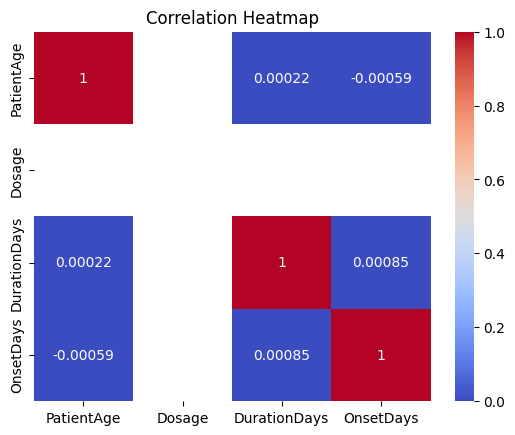

In [29]:
# Select numeric columns and calculate correlation
numeric_cols = ['PatientAge', 'Dosage', 'DurationDays', 'OnsetDays']
correlation_matrix = df[numeric_cols].corr()

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

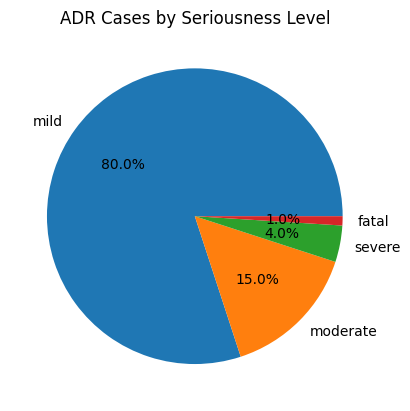

In [30]:
# Count seriousness levels
seriousness_counts = df['Seriousness'].value_counts()

# Create pie chart
plt.pie(seriousness_counts, labels=seriousness_counts.index, autopct='%1.1f%%')
plt.title('ADR Cases by Seriousness Level')
plt.show()

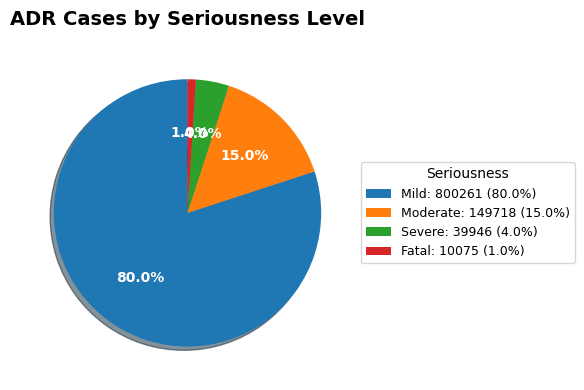

In [31]:
# Count seriousness levels
seriousness_counts = df['Seriousness'].value_counts()

# Cool color palette (modern & readable)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'][:len(seriousness_counts)]

# Create pie chart
plt.figure(figsize=(6,4))
wedges, texts, autotexts = plt.pie(
    seriousness_counts,
    labels=seriousness_counts.index.str.title(),
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    shadow=True,
    textprops={'fontsize':10, 'fontweight':'bold', 'color':'white'}
)

# Legend with counts & percentages
total = len(df)
legend_labels = [f"{lvl.title()}: {cnt} ({cnt/total*100:.1f}%)" 
                 for lvl, cnt in zip(seriousness_counts.index, seriousness_counts.values)]
plt.legend(wedges, legend_labels, title="Seriousness", loc="center left", 
           bbox_to_anchor=(1,0.5), fontsize=9)

plt.title('ADR Cases by Seriousness Level', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [32]:
concomitant_counts = df['ConcomitantDrugs'].str.split(',').explode().value_counts()
most_common = concomitant_counts.nlargest(5)
count = concomitant_counts.max()

print(f"{most_common} : {count}")

ConcomitantDrugs
                 437828
Levothyroxine     28428
Sertraline        28309
 Amoxicillin      28305
 Albuterol        28281
Name: count, dtype: int64 : 437828


In [33]:
df.head(2)

,ReportID,PatientAge,Gender,DrugName,Dosage,DurationDays,ConcomitantDrugs,ADR_Code,Seriousness,OnsetDays,NumConcomitant,AgeGroup
0,REP-VJpHH7RG,52,Other,Ibuprofen,None,31,"Simvastatin, Fluoxetine, Gabapentin",10016256,mild,12,3,51-70
1,REP-xZHEIV6F,64,Male,Atorvastatin,None,33,,10019211,mild,5,0,51-70


In [34]:
# Which ADR_Code is reported the most?
count_adr = df['ADR_Code'].value_counts()
max_adr = count_adr.idxmax()

print(f"maximum ADR count: {max_adr}")

maximum ADR count: 10037844


In [35]:
# Filter severe cases and group by Drug and Gender
severe_by_drug_gender = df[df['Seriousness'] == 'severe'].groupby(['DrugName', 'Gender']).size()
print(f"{severe_by_drug_gender}")

DrugName             Gender
Albuterol            Female     949
                     Male      1014
                     Other       77
Amlodipine           Female     951
                     Male      1025
                     Other       75
Amoxicillin          Female     981
                     Male       910
                     Other       88
Aspirin              Female     944
                     Male       935
                     Other       84
Atorvastatin         Female     985
                     Male       933
                     Other       88
Citalopram           Female     961
                     Male       922
                     Other       69
Fluoxetine           Female     909
                     Male       932
                     Other       69
Gabapentin           Female     924
                     Male       982
                     Other       76
Hydrochlorothiazide  Female     935
                     Male       967
                     Other       78
